# 1. Import

In [ ]:
# --- plot_revision setup ---
import sys
from pathlib import Path
_HERE = Path.cwd().resolve()
for cand in (_HERE.parent, _HERE / "plot_revision", _HERE):
    if (cand / "paths.py").exists():
        sys.path.insert(0, str(cand))
        break
from paths import (
    REPO, ensure_out_dir,
    RESULT_DIR, RESULT_HUMAN_DIR, RESULT_MOUSE_DIR, RESULT_MULTI_DIR,
    SPC_MULTI_CSV, CLAUDE_CLADE_DIR, TREE_NWK,
    RESULT_RETRIEVAL_DIR, GAP_HUMAN_CSV, GAP_MOUSE_CSV,
    CKPT_ROOT, EPI_EVO2HIC_DIR, PRETRAIN_CKPT_DIR, PRETRAIN_CKPT,
    SR_EVO2HIC_HUMAN_DIR, SEQ2HIC_CKPT,
    HIC_DATA_ROOT, HIC_RAW_DIR, HIC_RAW, DNA_FASTA, MOTIF_MEME,
    EVO2_EMB_HUMAN, EVO2_EMB_MOUSE, TRACKS_GM12878_CHR10_NPY,
    ORCA_MALLPREDS_PTH, ORCA_EXPECTED_NPY,
    MOTIF_STATS_CSV,
    HUMAN_MERGED_CSV, HUMAN_INTER_DIR,
    HIC2TRACK_DIR, HIC2TRACK,
)
OUT_DIR = ensure_out_dir()
# Make `dataset.*` / `config` importable inside notebook cells
from paths import add_repo_to_syspath
add_repo_to_syspath()


In [ ]:

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
# --------------------------------------------------------
# References:
# Sagittarius to https://github.com/addiewc/Sagittarius
# --------------------------------------------------------
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

from plot_settings import colors as candidate_colors
from plot_utils import plot_box_with_points

import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-white')

In [2]:
import matplotlib as mpl
plt.rcParams.update({'font.size': 8})
print("xtick.labelsize:", mpl.rcParams['xtick.labelsize'])
print("ytick.labelsize:", mpl.rcParams['ytick.labelsize'])
print("axes.labelsize:", mpl.rcParams['axes.labelsize'])
print("axes.titlesize:", mpl.rcParams['axes.titlesize'])
print("legend.fontsize:", mpl.rcParams['legend.fontsize'])


xtick.labelsize: medium
ytick.labelsize: medium
axes.labelsize: medium
axes.titlesize: large
legend.fontsize: medium


# 4. DNA zoo

[]

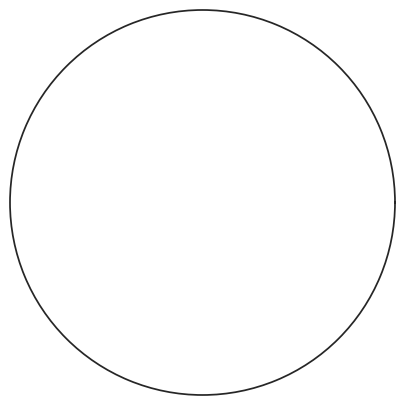

In [5]:
fig = plt.figure(figsize=(8.27, 5))


# 第三行单独一个大图，占据4列
ax_bottom = fig.add_subplot(1,1,1, projection='polar')
ax_bottom.set_xticks([]); ax_bottom.set_yticks([])


In [6]:
ax_bottom.clear()

def name_mapping(species):
    synonym = {
        'Herpailurus_yagouaroundi' : 'Puma_yagouaroundi',
        'Eulemur_collaris' : 'Eulemur_fulvus_collaris',
    }
    if species in synonym:
        return synonym[species]

    if '__' in species:
        return species.split('__')[0]

    return species
    

result = pd.read_csv(str(SPC_MULTI_CSV), sep='\t')
species_list = [name_mapping(s) for s in result['species'].tolist()]

print(len(result))
print(len(set(species_list)))

from pycirclize import Circos
from collections import defaultdict
from pycirclize.utils import ColorCycler
import math

tree_file = str(TREE_NWK)
circos, tv = Circos.initialize_from_tree(
    tree_file,
    start=-90,
    end=270,
    r_lim=(30, 80),
    # leaf_label_rmargin=21,
    leaf_label_size=5,
    ignore_branch_length=True,
    label_formatter=lambda t: t.replace("_", " "),
)

#tv : TreeViz TreeViz instance pycirclize/tree.py
claude_dir = str(CLAUDE_CLADE_DIR) + '/'
claude_name_list=["Angiosperms","Protostomes","Actinopterygii","Reptilia","Mammalia","Marsupialia"]
group_name2species_list=defaultdict(list)

for claude_name in claude_name_list:
    cur_path=claude_dir+f"claude_{claude_name}_clean.txt"
    with open(cur_path,"r") as file:
        for line in file:
            cur_name=line.strip("\n")
            group_name2species_list[claude_name].append(cur_name)

# Set tree line color & label color

S = set(tv.leaf_labels)
ColorCycler.set_cmap("tab10")
group_name2color = {name: ColorCycler() for name in group_name2species_list.keys()}
for group_name, sps in group_name2species_list.items():
    color = group_name2color[group_name]
    S.difference_update(set(sps))
    sps = list(set(sps).intersection(set(tv.leaf_labels)))
    tv.set_node_line_props(sps, color=color, apply_label_color=True)


# Plot figure & set legend on center
circos.plotfig(ax=ax_bottom)
_ = circos.ax.legend(
    handles=[Line2D([], [], label=n, color=c) for n, c in group_name2color.items()],
    labelcolor=group_name2color.values(),
    fontsize=7,
    loc="center",
    bbox_to_anchor=(0.5, 0.505),
)

fig

177
176


ModuleNotFoundError: No module named 'pycirclize'

In [ ]:
fig.savefig(str(OUT_DIR / 'Fig1_multispecies.pdf'))